In [6]:
from google.colab import files
uploaded = files.upload()


Saving train.csv to train.csv
Saving gender_submission.csv to gender_submission.csv
Saving test.csv to test.csv


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

titanic = pd.read_csv("train.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [28]:
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")
sub_df   = pd.read_csv("gender_submission.csv")

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
X = train_df.drop("Survived", axis=1)
y = train_df["Survived"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(len(X_train), len(X_test))
print("Survival rate full:", y.mean())
print("Survival rate test:", y_test.mean())


712 179
Survival rate full: 0.3838383838383838
Survival rate test: 0.3854748603351955


In [30]:
X_train.info()
X_train.describe()
X_train.isna().sum().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    object 
 10  Embarked     710 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 66.8+ KB


,0
Cabin,552
Age,137
Embarked,2
Name,0
Pclass,0
PassengerId,0
Sex,0
Parch,0
SibSp,0
Fare,0


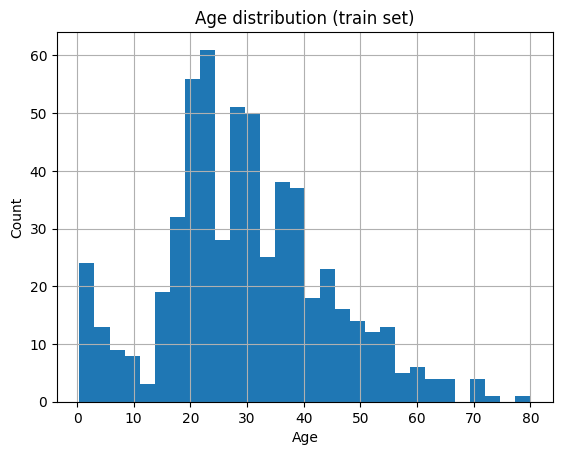

In [31]:
X_train["Age"].hist(bins=30)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age distribution (train set)")
plt.show()


Sex
female    0.743083
male      0.185185
Name: Survived, dtype: float64


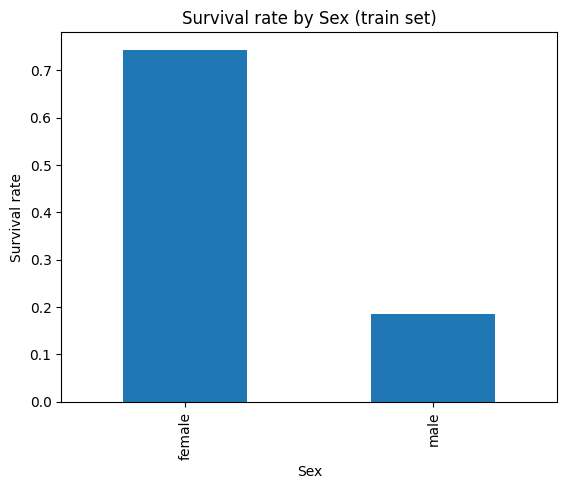

In [32]:
train_tmp = X_train.copy()
train_tmp["Survived"] = y_train.values

surv_by_sex = train_tmp.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
print(surv_by_sex)

surv_by_sex.plot(kind="bar")
plt.ylabel("Survival rate")
plt.title("Survival rate by Sex (train set)")
plt.show()


Pclass
1    0.649123
2    0.446667
3    0.242967
Name: Survived, dtype: float64


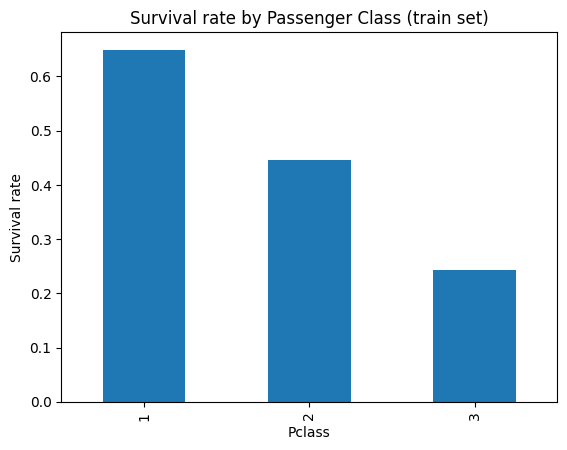

In [33]:
surv_by_class = train_tmp.groupby("Pclass")["Survived"].mean()
print(surv_by_class)

surv_by_class.plot(kind="bar")
plt.ylabel("Survival rate")
plt.title("Survival rate by Passenger Class (train set)")
plt.show()

In [34]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # CabinDeck: first letter of Cabin (A, B, C...) or "Unknown"
    df["CabinDeck"] = df["Cabin"].fillna("Unknown").astype(str).str[0]

    # Family features (often helpful)
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    # Drop columns we won't use directly
    df = df.drop(["Cabin", "Ticket", "Name"], axis=1)

    return df


In [35]:
X_train_fe = add_features(X_train)
X_test_fe  = add_features(X_test)

X_train_fe.head()


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinDeck,FamilySize,IsAlone
692,693,3,male,NaN,0,0,56.4958,S,U,1,1
481,482,2,male,NaN,0,0,0.0000,S,U,1,1
527,528,1,male,NaN,0,0,221.7792,S,C,1,1
855,856,3,female,18.0,0,1,9.3500,S,U,2,0
801,802,2,female,31.0,1,1,26.2500,S,U,3,0


In [36]:
num_attribs = X_train_fe.select_dtypes(include=[np.number]).columns.tolist()
cat_attribs = X_train_fe.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, num_attribs),
    ("cat", categorical_pipeline, cat_attribs),
])

model = LogisticRegression(max_iter=1000)

clf = Pipeline([
    ("preprocess", preprocess),
    ("model", model),
])

clf.fit(X_train_fe, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['PassengerId', 'Pclass',
                                                   'Age', 'SibSp', 'Parch',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'CabinDeck'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [37]:
y_pred = clf.predict(X_test_fe)

acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Test accuracy: 0.8100558659217877

Confusion matrix:
 [[97 13]
 [21 48]]

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179

